<a href="https://colab.research.google.com/github/Amarnath2908/Natural_Language_processing/blob/main/NLP1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import files
uploaded = files.upload()

Saving IMDB_Dataset.csv to IMDB_Dataset.csv


In [ ]:
df = pd.read_csv("IMDB_Dataset.csv")

In [ ]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df['sentiment'].value_counts()

,count
sentiment,
positive,25000
negative,25000


In [ ]:
df.shape

(50000, 2)

In [ ]:
df['review'].head()

,review
0,One of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...
2,I thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is..."


In [ ]:

df['review_length'] = df['review'].apply(lambda x: len(str(x).split()))

avg_length = df['review_length'].mean()

print("Average Review Length:", avg_length)

Average Review Length: 231.15694


# Task 3 — Text Preprocessing
Raw text cannot be fed directly into neural networks.
You must perform preprocessing:


Tasks:
Convert text to lowercase
Remove punctuation
Remove HTML tags
Tokenize words
Remove stopwords
Convert words → sequences


Expected output example:
Original:
"This movie was absolutely fantastic!"
Processed:
["movie", "absolutely", "fantastic"]


In [ ]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize



stop_words = set(stopwords.words('english'))

processed_reviews = []

for i in range(len(df)):
    # 1. Convert to lowercase
    text = df.loc[i, 'review'].lower()

    # 2. Remove HTML tags
    text = re.sub(r'<.*?>', '', text)

    # 3. Remove punctuation
    text = re.sub('[^a-zA-Z]',' ',text)

    # 4. Tokenize words
    words = word_tokenize(text)

    # 5. Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Store processed words
    processed_reviews.append(words)

# Add new column
df['processed_review'] = processed_reviews

# Show sample output
print("Original:", df['review'].iloc[0])
print("Processed:", df['processed_review'].iloc[0])

Original: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due 

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert tokenized words list into string format
df['processed_text_str'] = df['processed_review'].apply(lambda x: ' '.join(x))

tokenizer = Tokenizer(num_words=5000, oov_token="<OOV>")

# 2. Fit tokenizer on processed reviews
tokenizer.fit_on_texts(df['processed_text_str'])

# 3. Create vocabulary (word index mapping)
word_index = tokenizer.word_index

# 4. Convert reviews into sequences
sequences = tokenizer.texts_to_sequences(df['processed_text_str'])

# 5. (Optional) Pad sequences to make same length
padded_sequences = pad_sequences(sequences, maxlen=100, padding='post', truncating='post')

# Display sample outputs
print("Sample Processed Review:")
print(df['processed_text_str'].iloc[0])

print("\nSequence for first review:")
print(sequences[0])

print("\nPadded Sequence for first review:")
print(padded_sequences[0])

print("\nWord Index Mapping (First 10 words):")
for word, index in list(word_index.items())[:10]:
    print(word, ":", index)

Sample Processed Review:
one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home many aryans muslims gangstas latinos christians italians irish scuffles death stares dodgy dealings shady agreements never far away would say main appeal show due fact goes shows dare forget pretty pictures painted mainstream audiences forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards sold nickel inmates kill order get away well mannered middle class inmates turned prison bitch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Vocabulary size (same as tokenizer)
vocab_size = 5000

# Maximum review length (same as pad_sequences maxlen)
sequence_length = 100

# Build RNN model
model = Sequential()

# Embedding Layer
model.add(Embedding(input_dim=vocab_size, output_dim=64, input_length=sequence_length))

# SimpleRNN Layer
model.add(SimpleRNN(50, activation='tanh'))

# Dense Output Layer
model.add(Dense(1, activation='sigmoid'))   # Binary classification (positive/negative)

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Print model summary
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, classification_report
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(df['sentiment'])   # Replace 'sentiment' if needed

# Features
X = padded_sequences

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)


Training data shape: (40000, 100)
Testing data shape: (10000, 100)


Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5081 - loss: 0.6953 - val_accuracy: 0.5310 - val_loss: 0.6910
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5333 - loss: 0.6892 - val_accuracy: 0.5512 - val_loss: 0.6859
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.5607 - loss: 0.6762 - val_accuracy: 0.5550 - val_loss: 0.6921
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.5855 - loss: 0.6528 - val_accuracy: 0.5642 - val_loss: 0.7010
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 11s 9ms/step - accuracy: 0.6061 - loss: 0.6283 - val_accuracy: 0.5148 - val_loss: 0.7263


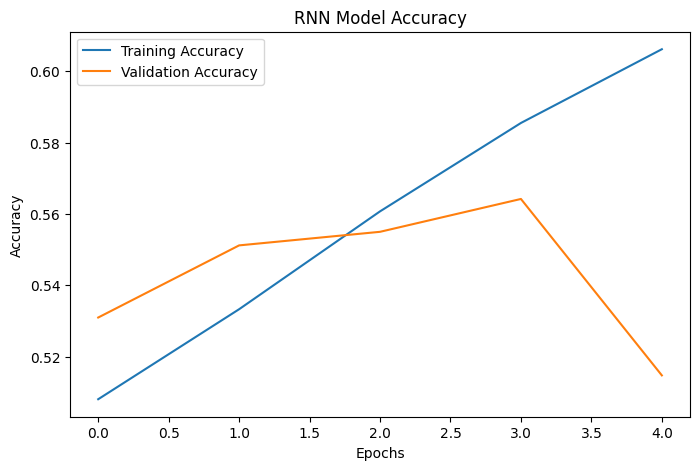

In [ ]:

history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)



plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('RNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step

Accuracy: 0.5148

Confusion Matrix:
 [[1850 3150]
 [1702 3298]]

Precision: 0.5114764267990074
Recall: 0.6596

Classification Report:

              precision    recall  f1-score   support

    negative       0.52      0.37      0.43      5000
    positive       0.51      0.66      0.58      5000

    accuracy                           0.51     10000
   macro avg       0.52      0.51      0.50     10000
weighted avg       0.52      0.51      0.50     10000



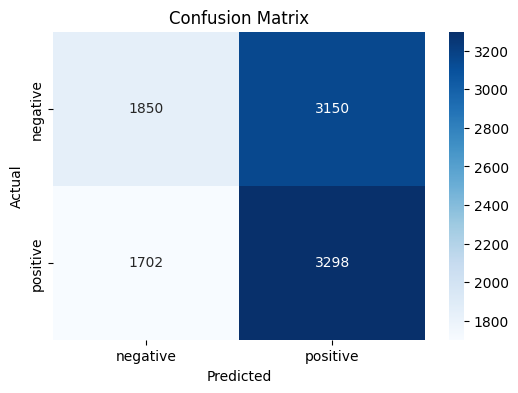


Number of Misclassified Reviews: 4852

Sample Misclassified Reviews:

Review: One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never

In [ ]:

# Predict probabilities
y_pred_prob = model.predict(X_test)

# Convert probabilities to class labels
y_pred = (y_pred_prob > 0.5).astype("int32")

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("\nAccuracy:", acc)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:\n", cm)

# Precision and Recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print("\nPrecision:", precision)
print("Recall:", recall)

# Full classification report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))

# Plot confusion matrix
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# -------------------------------
# Misclassified Reviews Analysis
# -------------------------------

# Find misclassified indices
misclassified_indices = np.where(y_test != y_pred.flatten())[0]

print("\nNumber of Misclassified Reviews:", len(misclassified_indices))

# Display first 5 misclassified reviews
print("\nSample Misclassified Reviews:\n")
for i in misclassified_indices[:5]:
    print("Review:", df['review'].iloc[i])
    print("Actual Label:", label_encoder.inverse_transform([y_test[i]])[0])
    print("Predicted Label:", label_encoder.inverse_transform([y_pred[i][0]])[0])
    print("-" * 80)
